<a href="https://colab.research.google.com/github/GerardoMunoz/AlgLin_2025/blob/main/cuestionarios/Aplicaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. Lucas–Kanade con ventanas 2×2

A continuación se ilustran los pasos para calcular la velocidad con la que se mueve una imagen. Para simplificar, en vez de tomar toda la imagen solo tomaremos una ventana de 2x2 pixeles. Y asumimos que al mover esa ventana a una velocidad $(v_x,v_y)$ (flecha roja) obtenemos la ventana del siguiente frame, (el tiempo está medido en frames)

$$I(x+v_x,y+v_y,t)≈I(x,y,t+1)$$

Usando la pseudoinversa, encontramos la velocidad $(u,v)$ que minimiza el error.


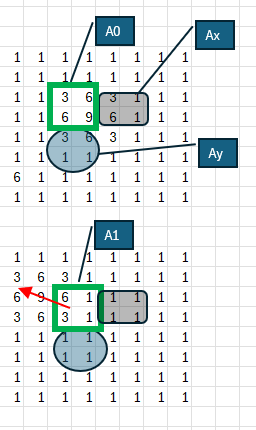





Se tienen cuatro ventanas de tamaño $2\times2$ provenientes de una secuencia de imágenes:
$A_0$ es la ventana de $2\times2$
$$
A_0 =
\begin{bmatrix}
1 & 2 \\
3 & 4
\end{bmatrix}
$$
$A_x$ es una ventana desplazada en $x$
$$
A_x =
\begin{bmatrix}
2 & 2 \\
4 & 4
\end{bmatrix}
$$
$A_y$ es una ventana desplazada en $y$
$$
A_y =
\begin{bmatrix}
1 & 2 \\
1 & 2
\end{bmatrix}
$$
$A_1$ es la misma ventana $A_0$ pero del siguiente frame
$$
A_1 =
\begin{bmatrix}
1 & 1 \\
1 & 3
\end{bmatrix}
$$

---

## 🔹 Paso 1: Derivadas espaciales y temporal

Calcule las siguientes matrices:

$$
D_x = A_0 - A_x=\begin{bmatrix}
\quad & \quad \\
\quad & \quad
\end{bmatrix}
$$
$$
D_y = A_0 - A_y=\begin{bmatrix}
\quad & \quad \\
\quad & \quad
\end{bmatrix}
$$
$$
D_t = A_0 - A_1=\begin{bmatrix}
\quad & \quad \\
\quad & \quad
\end{bmatrix}
$$
---

## 🔹 Paso 2: Expresión en la base estándar

Dada una matriz de $2 \times 2$:

$$ D=
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

Sus coordenadas en la base estándar son:

$$
I=\begin{pmatrix}
a \\ b \\
c \\ d
\end{pmatrix}
$$

Encuentre las coordenadas del las matrices $D_x, D_y, D_t$ respectivamente:

$$
I_x=\begin{pmatrix}
\quad \\  \\ \\
\end{pmatrix}
\quad I_y=\begin{pmatrix}
\quad \\  \\
 \\
\end{pmatrix}
\quad I_t=\begin{pmatrix}
\quad \\  \\
 \\
\end{pmatrix}
$$
---

## 🔹 Paso 3: Construcción del sistema lineal

El sistema de ecuaciones con variables $v_x, v_y$, denotado de cualqiuera de estas formas:
$$
v_x I_x + v_yI_y=I_t
$$

$$
\begin{bmatrix}
I_x &
I_y
\end{bmatrix}
\begin{bmatrix}
v_x \\
v_y
\end{bmatrix}
=I_t
$$
usualmente es inconsistente ya que hay más ecuaciones que incógnitas, por tal motivo para encontrar las variables $v_x, v_y$ se utilizan mínimos cuadrados. Por lo tanto se define la matriz $C$ de $4 \times 2$


$C=[I_x \quad I_y]=\begin{bmatrix}
\quad & \quad \\ & \\ & \\ &
\end{bmatrix}$


---

## 🔹 Paso 4: Resolución por mínimos cuadrados

$$
\begin{bmatrix}
v_x \\
v_y
\end{bmatrix}=
(C^TC)^{-1}C^TI_t
$$
Calcule:

$$
C^TC=\begin{bmatrix}
\quad & \quad \\ & \\
\end{bmatrix}
$$

$$
(C^TC)^{-1}=\begin{bmatrix}
\quad & \quad \\ & \\
\end{bmatrix}
$$

$$
(C^TC)^{-1}C^T=\begin{bmatrix}
\quad & \quad &\quad & \quad \\ & \\
\end{bmatrix}
$$

$$
(C^TC)^{-1}C^TI_t=\begin{bmatrix}
\quad & \\ & \\
\end{bmatrix}
$$


## 🔹 Paso 5: Interpretación

Interprete el resultado $v_x,v_y$:

* ¿En qué dirección se mueve el parche?




In [124]:
#Lucas Kanade

import sympy as sp

A0=sp.Matrix([[1,2],[3,4]])
Ax=sp.Matrix([[2,2],[4,4]])
Ay=sp.Matrix([[1,2],[1,2]])
A1=sp.Matrix([[1,1],[1,3]])
Dx=A0-Ax
Dy=A0-Ay
Dt=A0-A1
print("Dx:")
display(Dx)
print("Dy:")
display(Dy)
print("Dt:")
display(Dt)

Dx:


Matrix([
[-1, 0],
[-1, 0]])

Dy:


Matrix([
[0, 0],
[2, 2]])

Dt:


Matrix([
[0, 1],
[2, 1]])

In [125]:
Ix = Dx.reshape(4, 1)
print("Ix:")
display(Ix)
Iy = Dy.reshape(4, 1)
print("Iy:")
display(Iy)
It = Dt.reshape(4, 1)
print("It:")
display(It)

Ix:


Matrix([
[-1],
[ 0],
[-1],
[ 0]])

Iy:


Matrix([
[0],
[0],
[2],
[2]])

It:


Matrix([
[0],
[1],
[2],
[1]])

In [126]:
C=Ix.row_join(Iy)
print("C:")
display(C)

C:


Matrix([
[-1, 0],
[ 0, 0],
[-1, 2],
[ 0, 2]])

In [127]:
(C.T@C)

Matrix([
[ 2, -2],
[-2,  8]])

In [128]:
(C.T@C).inv()

Matrix([
[2/3, 1/6],
[1/6, 1/6]])

In [129]:
(C.T@C).inv()@C.T

Matrix([
[-2/3, 0, -1/3, 1/3],
[-1/6, 0,  1/6, 1/3]])

In [130]:
(C.T@C).inv()@C.T@It

Matrix([
[-1/3],
[ 2/3]])

# 2. Cinemática directa de un robot planar (2R)

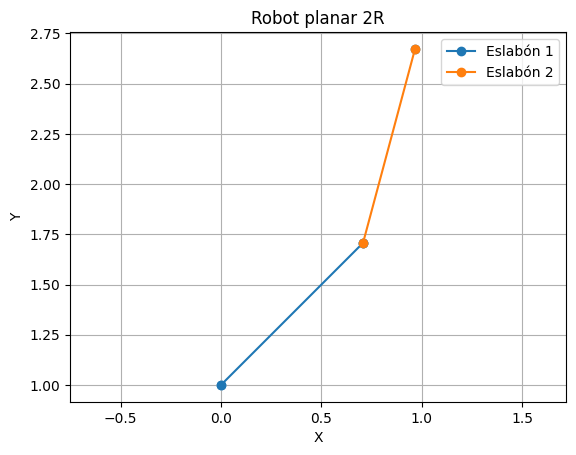

In [131]:
import numpy as np
import matplotlib.pyplot as plt

# Longitudes de los eslabones
l1 = 1
l2 = 1

# Ángulos (en radianes)
theta1 = 45*np.pi / 180   # 90°
theta2 = 30*np.pi / 180   # 90°

# Posición de la primera articulación
x0, y0 = 0, 0

# Posición del primer eslabón
x1 = l1 * np.cos(theta1)
y1 = l1 * np.sin(theta1)

# Posición del efector final
x2 = x1 + l2 * np.cos(theta1 + theta2)
y2 = y1 + l2 * np.sin(theta1 + theta2)

# Crear figura
plt.figure()

# Dibujar robot
plt.plot([x0, x1], [y0+1, y1+1], 'o-', label='Eslabón 1')
plt.plot([x1, x2], [y1+1, y2+1], 'o-', label='Eslabón 2')

# Marcar puntos
plt.scatter([x0, x1, x2], [y0+1, y1+1, y2+1])

# Configuración gráfica
plt.title("Robot planar 2R")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

In [132]:
T2=sp.Matrix([
    [1,  0, 1],
    [0,  1, 0],
    [0,  0, 1]])
T2

Matrix([
[1, 0, 1],
[0, 1, 0],
[0, 0, 1]])

In [133]:
import sympy as sp
import math
alpha2=30*math.pi/180#sp.symbols('a2')#
R2=sp.Matrix([
    [sp.cos(alpha2),-sp.sin(alpha2), 0],
    [sp.sin(alpha2), sp.cos(alpha2), 0],
    [0,              0,              1]])
R2


Matrix([
[0.866025403784439,              -0.5, 0],
[              0.5, 0.866025403784439, 0],
[                0,                 0, 1]])

In [134]:
display(R2)

Matrix([
[0.866025403784439,              -0.5, 0],
[              0.5, 0.866025403784439, 0],
[                0,                 0, 1]])

In [135]:
T1=sp.Matrix([
    [1,  0, 1],
    [0,  1, 0],
    [0,  0, 1]])
T1

Matrix([
[1, 0, 1],
[0, 1, 0],
[0, 0, 1]])

In [136]:
import sympy as sp
import math
alpha1=45*math.pi/180#sp.symbols('a1')#
R1=sp.Matrix([
    [sp.cos(alpha1),-sp.sin(alpha1), 0],
    [sp.sin(alpha1), sp.cos(alpha1), 0],
    [0,              0,              1]])
R1

Matrix([
[0.707106781186548, -0.707106781186547, 0],
[0.707106781186547,  0.707106781186548, 0],
[                0,                  0, 1]])

In [137]:
T0=sp.Matrix([
    [1,  0, 0],
    [0,  1, 1],
    [0,  0, 1]])
T0

Matrix([
[1, 0, 0],
[0, 1, 1],
[0, 0, 1]])

In [138]:
T=T0@R1@T1@R2@T2
T

Matrix([
[0.258819045102521, -0.965925826289068, 0.965925826289068],
[0.965925826289068,  0.258819045102521,  2.67303260747562],
[                0,                  0,                 1]])

In [139]:
T[0,2],T[1,2]

(0.965925826289068, 2.67303260747562)

In [140]:
(math.cos(45*math.pi/180)+math.cos(75*math.pi/180),1+math.sin(45*math.pi/180)+math.sin(75*math.pi/180))

(0.9659258262890683, 2.6730326074756157)

# 3. Intersección de rectas

In [141]:
%%html
<svg xmlns="http://w3.org" viewBox="0 0 500 300" width="100%" height="100%" style="background-color: white;">
  <!-- DEFINICIONES DE ESTILOS -->
  <style>
    .grid-minor { stroke: #e2e8f0; stroke-width: 0.5; }
    .grid-major { stroke: #cbd5e1; stroke-width: 1; }
    .axis { stroke: #334155; stroke-width: 1.5; }
    .axis-text { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif; font-size: 14px; fill: #1e293b; text-anchor: middle; }
    .geometry-line { stroke: #1e3a8a; stroke-width: 2; stroke-linecap: round; stroke-linejoin: round; fill: none; }
    .geometry-rect { stroke: #0f172a; stroke-width: 2; fill: none; }
    .geometry-node { fill: white; stroke: #1e3a8a; stroke-width: 1.5; }
    .label-p { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif; font-size: 16px; font-weight: bold; fill: #0f172a; text-anchor: middle; }
  </style>

  <!-- REJILLA/GRID (Cada cuadro mayor vale 1 unidad, subdividido en 0.5) -->
  <!-- Líneas Verticales -->
  <line x1="25" y1="20" x2="25" y2="245" class="grid-minor" />
  <line x1="50" y1="20" x2="50" y2="245" class="grid-major" />
  <line x1="75" y1="20" x2="75" y2="245" class="grid-minor" />
  <line x1="100" y1="20" x2="100" y2="245" class="grid-major" />
  <line x1="125" y1="20" x2="125" y2="245" class="grid-minor" />
  <line x1="150" y1="20" x2="150" y2="245" class="grid-major" />
  <line x1="175" y1="20" x2="175" y2="245" class="grid-minor" />
  <line x1="200" y1="20" x2="200" y2="245" class="grid-major" />
  <line x1="225" y1="20" x2="225" y2="245" class="grid-minor" />

  <line x1="275" y1="20" x2="275" y2="245" class="grid-minor" />
  <line x1="300" y1="20" x2="300" y2="245" class="grid-major" />
  <line x1="325" y1="20" x2="325" y2="245" class="grid-minor" />
  <line x1="350" y1="20" x2="350" y2="245" class="grid-major" />
  <line x1="375" y1="20" x2="375" y2="245" class="grid-minor" />
  <line x1="400" y1="20" x2="400" y2="245" class="grid-major" />
  <line x1="425" y1="20" x2="425" y2="245" class="grid-minor" />
  <line x1="450" y1="20" x2="450" y2="245" class="grid-major" />
  <line x1="475" y1="20" x2="475" y2="245" class="grid-minor" />

  <!-- Líneas Horizontales -->
  <line x1="20" y1="230" x2="480" y2="230" class="grid-major" />
  <line x1="20" y1="205" x2="480" y2="205" class="grid-minor" />
  <line x1="20" y1="180" x2="480" y2="180" class="grid-major" />
  <line x1="20" y1="155" x2="480" y2="155" class="grid-minor" />
  <line x1="20" y1="130" x2="480" y2="130" class="grid-major" />
  <line x1="20" y1="105" x2="480" y2="105" class="grid-minor" />
  <line x1="20" y1="80" x2="480" y2="80" class="grid-major" />
  <line x1="20" y1="55" x2="480" y2="55" class="grid-minor" />
  <line x1="20" y1="30" x2="480" y2="30" class="grid-major" />

  <!-- EJES COORDENADOS -->
  <!-- Eje Y -->
  <line x1="250" y1="15" x2="250" y2="235" class="axis" />
  <!-- Marcas del Eje X -->
  <line x1="50" y1="225" x2="50" y2="230" class="axis" />
  <line x1="100" y1="225" x2="100" y2="230" class="axis" />
  <line x1="150" y1="225" x2="150" y2="230" class="axis" />
  <line x1="200" y1="225" x2="200" y2="230" class="axis" />
  <line x1="300" y1="225" x2="300" y2="230" class="axis" />
  <line x1="350" y1="225" x2="350" y2="230" class="axis" />
  <line x1="400" y1="225" x2="400" y2="230" class="axis" />
  <line x1="450" y1="225" x2="450" y2="230" class="axis" />

  <!-- ETIQUETAS DE LOS EJES -->
  <!-- Números Eje X -->
  <text x="50" y="250" class="axis-text">-4</text>
  <text x="100" y="250" class="axis-text">-3</text>
  <text x="150" y="250" class="axis-text">-2</text>
  <text x="200" y="250" class="axis-text">-1</text>
  <text x="240" y="245" class="axis-text">0</text>
  <text x="300" y="250" class="axis-text">1</text>
  <text x="350" y="250" class="axis-text">2</text>
  <text x="400" y="250" class="axis-text">3</text>
  <text x="450" y="250" class="axis-text">4</text>

  <!-- Números Eje Y -->
  <text x="240" y="184" class="axis-text">1</text>
  <text x="240" y="134" class="axis-text">2</text>
  <text x="240" y="84" class="axis-text">3</text>
  <text x="240" y="34" class="axis-text">4</text>

  <!-- BLOQUES / RECTÁNGULOS (Y de 0 a 1) -->
  <!-- Bloque Izquierdo (X: -3.8 a -0.15) -->
  <rect x="60" y="180" width="182.5" height="50" class="geometry-rect" />
  <!-- Bloque Derecho (X: 0.15 a 4.1) -->
  <rect x="257.5" y="180" width="197.5" height="50" class="geometry-rect" />

  <!-- LÍNEAS GEOMÉTRICAS (Funciones matemáticas exactas) -->
  <!-- Línea izquierda: pasa por (-3,0), (-2,1) y llega a P(2/3, 11/3) -->
  <!-- Línea derecha: de P(2/3, 11/3) pasa por (2,1) y termina en (2.5,0) -->
  <polyline points="100,230 150,180 283.33,46.67 350,180 375,230" class="geometry-line" />

  <!-- INTERSECCIONES / DIÁMETROS (Puntos calados en y=1) -->
  <circle cx="150" cy="180" r="3.5" class="geometry-node" />
  <circle cx="350" cy="180" r="3.5" class="geometry-node" />

  <!-- ETIQUETA PUNTO P -->
  <text x="283.33" y="38" class="label-p">P</text>
</svg>


Encuentre las coordenadas del punto $P$ sabiendo que la imagen se forma
en las coordenadas (x,y)=(-3, 0) y (x,y)=(2.5, 0) de cada cámara. Además se
sabe que el centro de la pupila de cada cámara es (-2, 1) y (2,1)

* Para la recta de la cámara izquierda:
$$(x_0,y_0)=(-3,0), \quad (x_1,y_1)=(-2, 1)$$
$$\frac{y-y_0}{x-x_0}=\frac{y_1-y_0}{x_1-x_0}$$
$$\frac{y-0}{x+3}=\frac{1-0}{-2+3}$$
$$y=x+3$$
$$-x+y=3$$
* Para la recta de la cámara derecha:
$$(x_0,y_0)=(2.5, 0), \quad (x_1,y_1)=(2,1)$$

$$\frac{y-y_0}{x-x_0}=\frac{y_1-y_0}{x_1-x_0}$$
$$\frac{y-0}{x-2.5}=\frac{1-0}{2-2.5}$$
$$-0.5y=x-2.5$$
$$-x-0.5y=-2.5$$

Ahora se resuelve el sistema de ecuaciones para encontrar la intersección de las rectas

In [142]:
import sympy as sp
M=sp.Matrix([[-1,1,3],[-1,-0.5,-2.5]])
M

Matrix([
[-1,    1,    3],
[-1, -0.5, -2.5]])

In [143]:
M[1,:] -= M[0,:]
M

Matrix([
[-1,    1,    3],
[ 0, -1.5, -5.5]])

In [144]:
M[1,:] /= -1.5
M

Matrix([
[-1,   1,                3],
[ 0, 1.0, 3.66666666666667]])

In [145]:
M[0,:] -= M[1,:]
M

Matrix([
[-1,   0, -0.666666666666667],
[ 0, 1.0,   3.66666666666667]])

In [146]:
M[0,:] = -M[0,:]
M

Matrix([
[1,   0, 0.666666666666667],
[0, 1.0,  3.66666666666667]])

In [147]:
(2/3,11/3)

(0.6666666666666666, 3.6666666666666665)

$$x=2/3, \quad y=11/3$$

# 4. Vectores Caracterísitcos

In [148]:
A=sp.Matrix([[2,0,1,2,1],[0,2,2,3,3],[0,0,-1,0,0],[0,0,0,-1,0],[0,0,0,0,-1]])
A

Matrix([
[2, 0,  1,  2,  1],
[0, 2,  2,  3,  3],
[0, 0, -1,  0,  0],
[0, 0,  0, -1,  0],
[0, 0,  0,  0, -1]])

In [149]:
l=sp.symbols('\lambda')
C=A-l*sp.eye(5)
C

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_995/1273496473.py:1: SyntaxWarning: invalid escape sequence '\l'
  l=sp.symbols('\lambda')


Matrix([
[2 - \lambda,           0,            1,            2,            1],
[          0, 2 - \lambda,            2,            3,            3],
[          0,           0, -\lambda - 1,            0,            0],
[          0,           0,            0, -\lambda - 1,            0],
[          0,           0,            0,            0, -\lambda - 1]])

El dereminante de la matriz caracteríaica nos da el polinomio característico. Y sus raices nos dan los valores caracterísiticos. En el caso de una matriz triangular, coinciden con la diagonal.

Los valores caracterísitcos son
* $\lambda_1=2$, con $MA_1=2$
* $\lambda_2=-1$ con $MA_2=3$

Para encontrar el espacio caracterísitico de $\lambda_1=2$ encontramos el conjunto la solución homogénea de la respectiva matriz caracterísitca. A continuación escribimos la matriz extendida de la matriz caracterísitca.

In [150]:
M1=(A-2*sp.eye(5)).row_join(sp.zeros(5,1))
M1

Matrix([
[0, 0,  1,  2,  1, 0],
[0, 0,  2,  3,  3, 0],
[0, 0, -3,  0,  0, 0],
[0, 0,  0, -3,  0, 0],
[0, 0,  0,  0, -3, 0]])

In [151]:
M2=sp.zeros(5,6)
M2[0:3,:]=M1[2:5,:]
M2[3:5,:]=M1[0:2,:]
M2

Matrix([
[0, 0, -3,  0,  0, 0],
[0, 0,  0, -3,  0, 0],
[0, 0,  0,  0, -3, 0],
[0, 0,  1,  2,  1, 0],
[0, 0,  2,  3,  3, 0]])

Debido a que cada uno de los 3 primeros renglones tiene solamente un valor en una columna diferente y cero en la demás, implica que los cambios hechos en cada columna no afectan las otras. Por tal motivo en este caso, se pueden eliminar los datos en esas columnas de los últimos dos renglones.

In [152]:
M2=sp.zeros(5,6)
M2[0:3,:]=M1[2:5,:]
M2

Matrix([
[0, 0, -3,  0,  0, 0],
[0, 0,  0, -3,  0, 0],
[0, 0,  0,  0, -3, 0],
[0, 0,  0,  0,  0, 0],
[0, 0,  0,  0,  0, 0]])

Asuminedo el nombre de las variables $x_1,x_2,x_3,x_4,x_5$
* Se asignan parámetros a las variables libres: $$x_1=t_1, \quad x_2=t_2.$$
* Se despejan las variables delanteras desde la última:
  $$x_5=0, \quad x_4=0, \quad x_3=0.$$
* Escribimos la solución general:
$$\begin{pmatrix}  x_1\\x_2\\x_3\\x_4\\x_5\end{pmatrix} =t_1\begin{pmatrix}  1\\0\\0\\0\\0\end{pmatrix}  
+t_2\begin{pmatrix}  0\\1\\0\\0\\0\end{pmatrix} $$

Por lo tanto una base de este espacio caracterísitco serían las siguientes columnas: $$\begin{bmatrix}  1&0\\0&1\\0&0\\0&0\\0&0\end{bmatrix} $$

y por lo tanto su $MG_1=2$, igual a la $MA_1$





Para encontrar el espacio caracterísitico de $\lambda_2=-1$ encontramos el conjunto de la solución homogénea de la respectiva matriz caracterísitca. A continuación escribimos la matriz extendida de la matriz caracterísitca.

In [153]:
M1=(A+1*sp.eye(5)).row_join(sp.zeros(5,1))
M1

Matrix([
[3, 0, 1, 2, 1, 0],
[0, 3, 2, 3, 3, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0]])

Asuminedo el nombre de las variables $x_1,x_2,x_3,x_4,x_5$
* Se asignan parámetros a las variables libres: $$x_3=t_1, \quad x_4=t_2, \quad x_5=t_3.$$
* Se despejan las variables delanteras desde la última:
  $$3x_2+2t_1+3t_2+3t_3=0 \quad \rightarrow \quad x_2= \frac{-2}{3}t_1-t_2-t_3$$
  $$3x_1+t_1+2t_2+1t_3=0 \quad \rightarrow \quad x_1= \frac{-1}{3}t_1-\frac{2}{3}t_2-\frac{1}{3}t_3$$
* Escribimos la solución general:
$$\begin{pmatrix}  x_1\\x_2\\x_3\\x_4\\x_5\end{pmatrix} =t_1\begin{pmatrix}  \frac{-1}{3}\\\frac{-2}{3}\\1\\0\\0\end{pmatrix}  
+t_2\begin{pmatrix}  \frac{-2}{3}\\-1\\0\\1\\0\end{pmatrix} +t_3\begin{pmatrix}  \frac{-1}{3}\\-1\\0\\0\\1\end{pmatrix} $$

Por lo tanto una base de este espacio caracterísitco serían las siguientes columnas: $$\begin{bmatrix}  \frac{-1}{3}&\frac{-2}{3}&\frac{-1}{3}\\\frac{-2}{3}&-1&-1\\1&0&0\\0&1&0\\0&0&1\end{bmatrix} $$

y por lo tanto su $MG_2=3$, igual a la $MA_2$.

---

Cómo todas las $MA_i$ son iguales a las $MG_i$ entonces la matris $A$ sí es diagonalizable. La matriz que diagonaliza $B$ el la formada por las bases de los espacios característicos. Y la matriz diagonal $D$ son los respectivos valores característicos.

$$B=\begin{bmatrix}  1&0&\frac{-1}{3}&\frac{-2}{3}&\frac{-1}{3}\\0&1&\frac{-2}{3}&-1&-1\\0&0&1&0&0\\0&0&0&1&0\\0&0&0&0&1\end{bmatrix}, \quad D=\begin{bmatrix}2&0&0&0&0\\0&2&0&0&0\\0&0&-1&0&0\\0&0&0&-1&0\\0&0&0&0&-1\end{bmatrix} $$


Para verificar miramos si $AB==BD$

In [154]:
A=sp.Matrix([[2,0,1,2,1],[0,2,2,3,3],[0,0,-1,0,0],[0,0,0,-1,0],[0,0,0,0,-1]])
A

Matrix([
[2, 0,  1,  2,  1],
[0, 2,  2,  3,  3],
[0, 0, -1,  0,  0],
[0, 0,  0, -1,  0],
[0, 0,  0,  0, -1]])

In [155]:
B=sp.Matrix([[1,0,-1/3,-2/3,-1/3],[0,1,-2/3,-1,-1],[0,0,1,0,0],[0,0,0,1,0],[0,0,0,0,1]])
B

Matrix([
[1, 0, -0.333333333333333, -0.666666666666667, -0.333333333333333],
[0, 1, -0.666666666666667,                 -1,                 -1],
[0, 0,                  1,                  0,                  0],
[0, 0,                  0,                  1,                  0],
[0, 0,                  0,                  0,                  1]])

In [156]:
D=sp.Matrix([[2,0,0,0,0],[0,2,0,0,0],[0,0,-1,0,0],[0,0,0,-1,0],[0,0,0,0,-1]])
D

Matrix([
[2, 0,  0,  0,  0],
[0, 2,  0,  0,  0],
[0, 0, -1,  0,  0],
[0, 0,  0, -1,  0],
[0, 0,  0,  0, -1]])

In [157]:
A@B

Matrix([
[2, 0, 0.333333333333333, 0.666666666666667, 0.333333333333333],
[0, 2, 0.666666666666667,                 1,                 1],
[0, 0,                -1,                 0,                 0],
[0, 0,                 0,                -1,                 0],
[0, 0,                 0,                 0,                -1]])

In [158]:
B@D

Matrix([
[2, 0, 0.333333333333333, 0.666666666666667, 0.333333333333333],
[0, 2, 0.666666666666667,                 1,                 1],
[0, 0,                -1,                 0,                 0],
[0, 0,                 0,                -1,                 0],
[0, 0,                 0,                 0,                -1]])

Cómo imprimir una matriz extendida en LaTex con los nombres de las variables (quitar los hline)
$$
\begin{array}{c;ccc|c;c}
 & x_1 & x_2 & x_3 & & \\
\left[ \vphantom{\begin{array}{c} a \\ a \\ a \\ a \end{array}} \right.
&
\begin{array}{c} a_{11} \\ a_{21} \\ \hline c_{11} \\ c_{21} \end{array}
&
\begin{array}{c} a_{12} \\ a_{22} \\ \hline c_{12} \\ c_{22} \end{array}
&
\begin{array}{c} b_{11} \\ b_{21} \\ \hline d_{11} \\ d_{21} \end{array}
&
\begin{array}{c} b_{12} \\ b_{22} \\ \hline d_{12} \\ d_{22} \end{array}
&
\left. \vphantom{\begin{array}{c} a \\ a \\ a \\ a \end{array}} \right]
\end{array}
$$

